# EDA, DATA PREPARATION AND MODEL BUILDING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.api.types import CategoricalDtype


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

sns.set_theme(style="whitegrid", context="notebook")

## LOAD AND STACK DATA

In [2]:
data_19 = pd.read_csv('../datasets/DATASET_2019.csv')
data_21 = pd.read_csv('../datasets/DATASET_2021.csv')
data_23 = pd.read_csv('../datasets/DATASET_2023.csv')

In [3]:
datasets = [data_19, data_21, data_23]
for data in datasets:
    print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 416661 entries, 0 to 416660
Data columns (total 33 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   year                           416661 non-null  int64  
 1   age_group_00                   410146 non-null  str    
 2   age_00                         410146 non-null  float64
 3   sex_00                         416661 non-null  str    
 4   race_00                        407891 non-null  str    
 5   weight_00                      387477 non-null  float64
 6   height_00                      398396 non-null  float64
 7   bmi_00                         383076 non-null  float64
 8   marital_status_00              413299 non-null  str    
 9   education_level_00             414922 non-null  str    
 10  education_00                   414922 non-null  float64
 11  employment_status_00           410363 non-null  str    
 12  income_level_00                337595 non

In [4]:
for data in datasets:
    print(data.columns, len(data.columns))

Index(['year', 'age_group_00', 'age_00', 'sex_00', 'race_00', 'weight_00',
       'height_00', 'bmi_00', 'marital_status_00', 'education_level_00',
       'education_00', 'employment_status_00', 'income_level_00', 'income_00',
       'general_health_00', 'gen_health_00', 'physical_health_days_00',
       'mental_health_days_00', 'poor_health_days_00', 'exercise_00',
       'smoked_100_cigarettes_00', 'drinks_alcohol_00', 'avg_drinks_p_day_00',
       'high_bp_00', 'high_cholesterol_00', 'had_stroke_00',
       'had_heart_attack_00', 'had_coronary_heart_disease_00',
       'cost_barrier_00', 'last_checkup_00', 'l_checkup_00',
       'has_personal_doctor_00', 'diabetes'],
      dtype='str') 33
Index(['year', 'age_group_00', 'age_00', 'sex_00', 'race_00', 'weight_00',
       'height_00', 'bmi_00', 'marital_status_00', 'education_level_00',
       'education_00', 'employment_status_00', 'income_level_01', 'income_01',
       'general_health_00', 'gen_health_00', 'physical_health_days_00',


### Fix column name mismatch in 2019 data
- income_level_00 => income_level_01
- income_00 => income_01

In [5]:
data_19.rename(columns={"income_level_00": "income_level_01", "income_00":"income_01"}, inplace=True)

Concatenate all data across the 3 years, preserving all columns.

In [6]:
combined_data = pd.concat(datasets, ignore_index=True, join="outer", axis=0)
combined_data.head()

,year,age_group_00,age_00,sex_00,race_00,weight_00,height_00,bmi_00,marital_status_00,education_level_00,education_00,employment_status_00,income_level_01,income_01,general_health_00,gen_health_00,physical_health_days_00,mental_health_days_00,poor_health_days_00,exercise_00,smoked_100_cigarettes_00,drinks_alcohol_00,avg_drinks_p_day_00,high_bp_00,high_cholesterol_00,had_stroke_00,had_heart_attack_00,had_coronary_heart_disease_00,cost_barrier_00,last_checkup_00,l_checkup_00,has_personal_doctor_00,diabetes
0,2019,40 to 44,5.0,Female,White,220.0,66.0,35.51,Never married,College 1 year to 3 years (Some college or technical school),5.0,A homemaker,"Less than $10,000",1.0,Very Good,2.0,0.0,30.0,30.0,False,True,False,NaN,Yes,NaN,False,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Non-diabetic
1,2019,60 to 64,9.0,Male,White,150.0,66.0,24.21,Divorced,College 1 year to 3 years (Some college or technical school),5.0,Unable to work,"Less than $10,000",1.0,Fair,4.0,3.0,12.0,5.0,True,True,False,NaN,Yes,NaN,False,False,False,False,Within the past year (< 12 months ago),1.0,No,Non-diabetic
2,2019,45 to 49,6.0,Female,White,148.0,61.0,27.96,Divorced,Grade 12 or GED (High school graduate),4.0,Employed for wages,"Less than $10,000",1.0,Good,3.0,0.0,10.0,5.0,True,True,True,2.0,Yes,True,False,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Diabetic
3,2019,45 to 49,6.0,Male,White,220.0,71.0,30.68,Married,Grade 12 or GED (High school graduate),4.0,Employed for wages,"$75,000 or more",8.0,Very Good,2.0,0.0,0.0,NaN,True,True,False,NaN,No,False,False,False,False,False,Within the past year (< 12 months ago),1.0,No,Non-diabetic
4,2019,65 to 69,10.0,Male,Black,283.0,73.0,37.33,Widowed,Grade 12 or GED (High school graduate),4.0,Retired,"$15,000 to less than $20,000",3.0,Fair,4.0,30.0,0.0,30.0,False,True,False,NaN,Yes,True,True,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Diabetic


In [7]:
combined_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1285657 entries, 0 to 1285656
Data columns (total 33 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   year                           1285657 non-null  int64  
 1   age_group_00                   1262286 non-null  str    
 2   age_00                         1262286 non-null  float64
 3   sex_00                         1285657 non-null  str    
 4   race_00                        1256801 non-null  str    
 5   weight_00                      1182980 non-null  float64
 6   height_00                      1221773 non-null  float64
 7   bmi_00                         1170319 non-null  float64
 8   marital_status_00              1273395 non-null  str    
 9   education_level_00             1279423 non-null  str    
 10  education_00                   1279423 non-null  float64
 11  employment_status_00           1263926 non-null  str    
 12  income_level_01          

### Save Stacked Data

In [9]:
combined_data.to_csv('../datasets/combined_19_21_23.csv', index=False)

## Data Cleaning

In [2]:
df = pd.read_csv('../datasets/combined_19_21_23.csv')
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1285657 entries, 0 to 1285656
Data columns (total 33 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   year                           1285657 non-null  int64  
 1   age_group_00                   1262286 non-null  str    
 2   age_00                         1262286 non-null  float64
 3   sex_00                         1285657 non-null  str    
 4   race_00                        1256801 non-null  str    
 5   weight_00                      1182980 non-null  float64
 6   height_00                      1221773 non-null  float64
 7   bmi_00                         1170319 non-null  float64
 8   marital_status_00              1273395 non-null  str    
 9   education_level_00             1279423 non-null  str    
 10  education_00                   1279423 non-null  float64
 11  employment_status_00           1263926 non-null  str    
 12  income_level_01          

,year,age_group_00,age_00,sex_00,race_00,weight_00,height_00,bmi_00,marital_status_00,education_level_00,education_00,employment_status_00,income_level_01,income_01,general_health_00,gen_health_00,physical_health_days_00,mental_health_days_00,poor_health_days_00,exercise_00,smoked_100_cigarettes_00,drinks_alcohol_00,avg_drinks_p_day_00,high_bp_00,high_cholesterol_00,had_stroke_00,had_heart_attack_00,had_coronary_heart_disease_00,cost_barrier_00,last_checkup_00,l_checkup_00,has_personal_doctor_00,diabetes
0,2019,40 to 44,5.0,Female,White,220.0,66.0,35.51,Never married,College 1 year to 3 years (Some college or technical school),5.0,A homemaker,"Less than $10,000",1.0,Very Good,2.0,0.0,30.0,30.0,False,True,False,NaN,Yes,NaN,False,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Non-diabetic
1,2019,60 to 64,9.0,Male,White,150.0,66.0,24.21,Divorced,College 1 year to 3 years (Some college or technical school),5.0,Unable to work,"Less than $10,000",1.0,Fair,4.0,3.0,12.0,5.0,True,True,False,NaN,Yes,NaN,False,False,False,False,Within the past year (< 12 months ago),1.0,No,Non-diabetic
2,2019,45 to 49,6.0,Female,White,148.0,61.0,27.96,Divorced,Grade 12 or GED (High school graduate),4.0,Employed for wages,"Less than $10,000",1.0,Good,3.0,0.0,10.0,5.0,True,True,True,2.0,Yes,True,False,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Diabetic
3,2019,45 to 49,6.0,Male,White,220.0,71.0,30.68,Married,Grade 12 or GED (High school graduate),4.0,Employed for wages,"$75,000 or more",8.0,Very Good,2.0,0.0,0.0,NaN,True,True,False,NaN,No,False,False,False,False,False,Within the past year (< 12 months ago),1.0,No,Non-diabetic
4,2019,65 to 69,10.0,Male,Black,283.0,73.0,37.33,Widowed,Grade 12 or GED (High school graduate),4.0,Retired,"$15,000 to less than $20,000",3.0,Fair,4.0,30.0,0.0,30.0,False,True,False,NaN,Yes,True,True,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Diabetic


In [3]:
df.isna().sum()

year                                  0
age_group_00                      23371
age_00                            23371
sex_00                                0
race_00                           28856
weight_00                        102677
height_00                         63884
bmi_00                           115338
marital_status_00                 12262
education_level_00                 6234
education_00                       6234
employment_status_00              21731
income_level_01                  258424
income_01                        258424
general_health_00                  3318
gen_health_00                      3318
physical_health_days_00           30333
mental_health_days_00             24451
poor_health_days_00              589923
exercise_00                       23624
smoked_100_cigarettes_00          64272
drinks_alcohol_00                 82303
avg_drinks_p_day_00              675409
high_bp_00                         4817
high_cholesterol_00              146900


> To fix:
- Handle missing data
- Rename columns, remove the suffixes

In [3]:
clean_column_names = {}

for column in df.columns:
    # split by underscores, and remove the last part, then join
    if '_' in column:
        clean_name = '_'.join(column.strip().split('_')[:-1])
        clean_column_names[column] = clean_name
    else:
        clean_column_names[column] = column.strip()
    
clean_column_names

{'year': 'year',
 'age_group_00': 'age_group',
 'age_00': 'age',
 'sex_00': 'sex',
 'race_00': 'race',
 'weight_00': 'weight',
 'height_00': 'height',
 'bmi_00': 'bmi',
 'marital_status_00': 'marital_status',
 'education_level_00': 'education_level',
 'education_00': 'education',
 'employment_status_00': 'employment_status',
 'income_level_01': 'income_level',
 'income_01': 'income',
 'general_health_00': 'general_health',
 'gen_health_00': 'gen_health',
 'physical_health_days_00': 'physical_health_days',
 'mental_health_days_00': 'mental_health_days',
 'poor_health_days_00': 'poor_health_days',
 'exercise_00': 'exercise',
 'smoked_100_cigarettes_00': 'smoked_100_cigarettes',
 'drinks_alcohol_00': 'drinks_alcohol',
 'avg_drinks_p_day_00': 'avg_drinks_p_day',
 'high_bp_00': 'high_bp',
 'high_cholesterol_00': 'high_cholesterol',
 'had_stroke_00': 'had_stroke',
 'had_heart_attack_00': 'had_heart_attack',
 'had_coronary_heart_disease_00': 'had_coronary_heart_disease',
 'cost_barrier_00': '

In [4]:
df.rename(columns=clean_column_names, inplace=True)
df.head()

,year,age_group,age,sex,race,weight,height,bmi,marital_status,education_level,education,employment_status,income_level,income,general_health,gen_health,physical_health_days,mental_health_days,poor_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,avg_drinks_p_day,high_bp,high_cholesterol,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,last_checkup,l_checkup,has_personal_doctor,diabetes
0,2019,40 to 44,5.0,Female,White,220.0,66.0,35.51,Never married,College 1 year to 3 years (Some college or technical school),5.0,A homemaker,"Less than $10,000",1.0,Very Good,2.0,0.0,30.0,30.0,False,True,False,NaN,Yes,NaN,False,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Non-diabetic
1,2019,60 to 64,9.0,Male,White,150.0,66.0,24.21,Divorced,College 1 year to 3 years (Some college or technical school),5.0,Unable to work,"Less than $10,000",1.0,Fair,4.0,3.0,12.0,5.0,True,True,False,NaN,Yes,NaN,False,False,False,False,Within the past year (< 12 months ago),1.0,No,Non-diabetic
2,2019,45 to 49,6.0,Female,White,148.0,61.0,27.96,Divorced,Grade 12 or GED (High school graduate),4.0,Employed for wages,"Less than $10,000",1.0,Good,3.0,0.0,10.0,5.0,True,True,True,2.0,Yes,True,False,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Diabetic
3,2019,45 to 49,6.0,Male,White,220.0,71.0,30.68,Married,Grade 12 or GED (High school graduate),4.0,Employed for wages,"$75,000 or more",8.0,Very Good,2.0,0.0,0.0,NaN,True,True,False,NaN,No,False,False,False,False,False,Within the past year (< 12 months ago),1.0,No,Non-diabetic
4,2019,65 to 69,10.0,Male,Black,283.0,73.0,37.33,Widowed,Grade 12 or GED (High school graduate),4.0,Retired,"$15,000 to less than $20,000",3.0,Fair,4.0,30.0,0.0,30.0,False,True,False,NaN,Yes,True,True,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Diabetic


#### Deal with missing data
- Drop all rows where age is missing
- Race is not to be used. Might drop the column altogether
- Verify where weight, height and bmi are missing
- drop all where bmi is missing

In [6]:
df.isna().sum()

year                               0
age_group                      23371
age                            23371
sex                                0
race                           28856
weight                        102677
height                         63884
bmi                           115338
marital_status                 12262
education_level                 6234
education                       6234
employment_status              21731
income_level                  258424
income                        258424
general_health                  3318
gen_health                      3318
physical_health_days           30333
mental_health_days             24451
poor_health_days              589923
exercise                       23624
smoked_100_cigarettes          64272
drinks_alcohol                 82303
avg_drinks_p_day              675409
high_bp                         4817
high_cholesterol              146900
had_stroke                      3452
had_heart_attack                6971
h

In [21]:
df[['age', 'age_group']][df['age'].isna()]

,age,age_group
70,NaN,NaN
83,NaN,NaN
193,NaN,NaN
236,NaN,NaN
562,NaN,NaN
...,...,...
1285449,NaN,NaN
1285484,NaN,NaN
1285499,NaN,NaN
1285505,NaN,NaN


In [7]:
# check if any of the rows have two of the parameters to infer the third
cols = ['weight', 'height', 'bmi']
df[df[cols].notna().sum(axis=1) == 2][cols]

,weight,height,bmi


In [28]:
df_1 = df.copy()
df_1.drop(columns=['poor_health_days', 'avg_drinks_p_day', 'high_cholesterol'], inplace=True)
df_1.dropna(inplace=True)
df_1.info()

<class 'pandas.DataFrame'>
Index: 869319 entries, 0 to 1285656
Data columns (total 30 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   year                        869319 non-null  int64  
 1   age_group                   869319 non-null  str    
 2   age                         869319 non-null  float64
 3   sex                         869319 non-null  str    
 4   race                        869319 non-null  str    
 5   weight                      869319 non-null  float64
 6   height                      869319 non-null  float64
 7   bmi                         869319 non-null  float64
 8   marital_status              869319 non-null  str    
 9   education_level             869319 non-null  str    
 10  education                   869319 non-null  float64
 11  employment_status           869319 non-null  str    
 12  income_level                869319 non-null  str    
 13  income                      8

In [36]:
df.diabetes.value_counts()

diabetes
Non-diabetic    1081246
Diabetic         174727
Pre-diabetic      29684
Name: count, dtype: int64

In [37]:
df_1.diabetes.value_counts()

diabetes
Non-diabetic    734009
Diabetic        115697
Pre-diabetic     19613
Name: count, dtype: int64

#### Fix category orders
- age_group
- education_level
- income_level
- gen_health
- last_checkup

In [29]:
df_1.age_group.unique()

<ArrowStringArray>
[   '40 to 44',    '60 to 64',    '45 to 49',    '65 to 69',    '55 to 59',
    '18 to 24',    '50 to 54', '80 or older',    '75 to 79',    '25 to 29',
    '35 to 39',    '70 to 74',    '30 to 34']
Length: 13, dtype: str

In [29]:
# fix age_group order
rename_age_groups = {
    '18 to 24': '18 - 24',
    '25 to 29': '25 - 29',
    '30 to 34': '30 - 34',
    '35 to 39': '35 - 39',
    '40 to 44': '40 - 44',
    '45 to 49': '45 - 49',
    '50 to 54': '50 - 54',
    '55 to 59': '55 - 59',
    '60 to 64': '60 - 64',
    '65 to 69': '65 - 69',
    '70 to 74': '70 - 74',
    '75 to 79': '75 - 79',
    '80 or older': '80+'
}

df_1['age_group'] = df_1['age_group'].replace(rename_age_groups)
age_categories = ['18 - 24', '25 - 29', '30 - 34', '35 - 39', '40 - 44', '45 - 49', '50 - 54', '55 - 59', '60 - 64',
                  '65 - 69', '70 - 74', '75 - 79', '80+']
age_cat_type = CategoricalDtype(categories=age_categories, ordered=True)
# Apply to a column
df_1['age_group'] = df_1['age_group'].astype(age_cat_type)

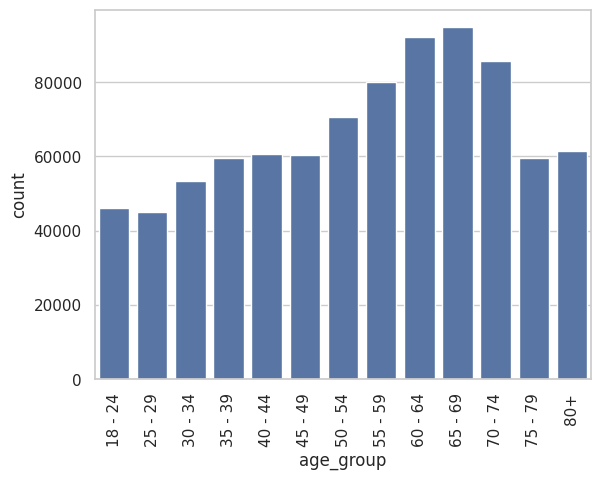

In [19]:
sns.countplot(data=df_1, x='age_group')
plt.xticks(rotation=90);

In [11]:
df_1.education_level.unique()

<ArrowStringArray>
['College 1 year to 3 years (Some college or technical school)',
                       'Grade 12 or GED (High school graduate)',
                   'College 4 years or more (College graduate)',
                             'Grades 9 - 11 (Some high school)',
                                    'Grades 1 - 8 (Elementary)',
                   'Never attended school or only kindergarten']
Length: 6, dtype: str

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'College 1 year to 3 years (Some college or technical school)'),
  Text(1, 0, 'Grade 12 or GED (High school graduate)'),
  Text(2, 0, 'College 4 years or more (College graduate)'),
  Text(3, 0, 'Grades 9 - 11 (Some high school)'),
  Text(4, 0, 'Grades 1 - 8 (Elementary)'),
  Text(5, 0, 'Never attended school or only kindergarten')])

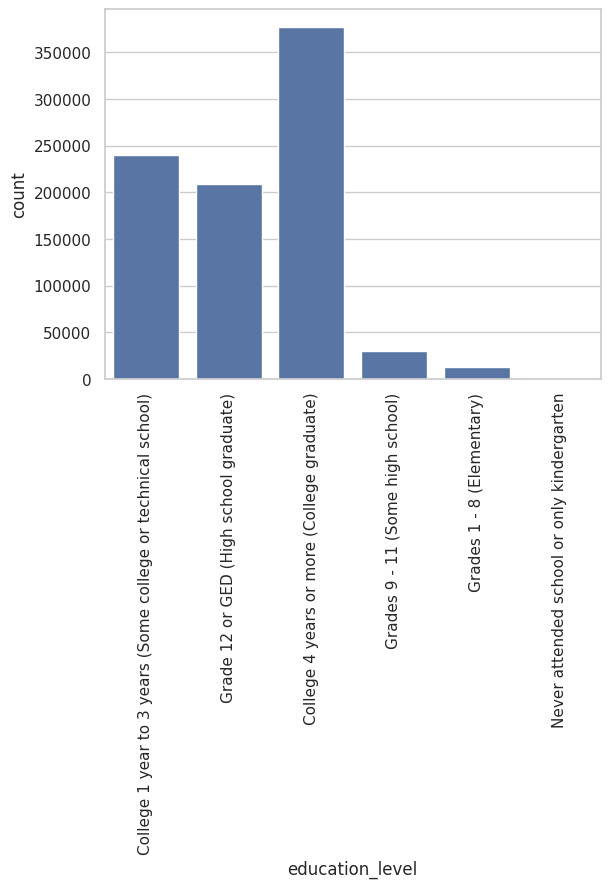

In [21]:
sns.countplot(data=df_1, x='education_level')
plt.xticks(rotation=90)

In [30]:
# fix education_level order
rename = {
    "Never attended school or only kindergarten" : "None or KG",
    "Grades 1 - 8 (Elementary)": "Elementary (1-8)",
    "Grades 9 - 11 (Some high school)": "Some high school (9-11)",
    "Grade 12 or GED (High school graduate)": "High school graduate (12 or GED)",
    "College 1 year to 3 years (Some college or technical school)": "Some college (1-3 years) or Technical school",
    "College 4 years or more (College graduate)": "College graduate (4+ years)"
}

df_1['education_level'] = df_1['education_level'].replace(rename)


education_categories = ['None or KG', 'Elementary (1-8)', 'Some high school (9-11)', 'High school graduate (12 or GED)',
                        'Some college (1-3 years) or Technical school', 'College graduate (4+ years)']
education_cat_type = CategoricalDtype(categories=education_categories, ordered=True)
# Apply to a column
df_1['education_level'] = df_1['education_level'].astype(education_cat_type)

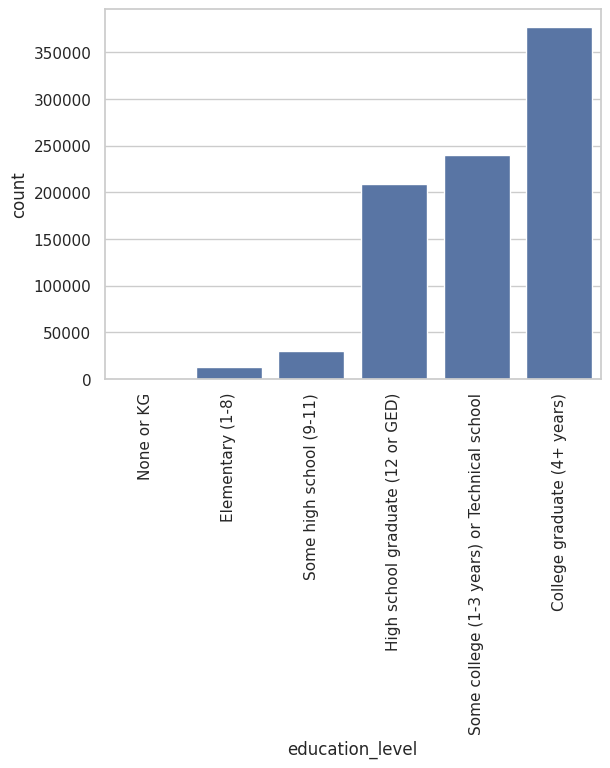

In [23]:
sns.countplot(data=df_1, x='education_level')
plt.xticks(rotation=90);

In [8]:
df_1.education_level.unique()

['Some college (1-3 years) or Technical school', 'High school graduate (12 or GED)', NaN, 'Some high school (9-11)', 'Elementary (1-8)', 'None or KG']
Categories (6, str): ['None or KG' < 'Elementary (1-8)' < 'Some high school (9-11)' < 'High school graduate (12 or GED)' < 'Some college (1-3 years) or Technical school' < 'College graduate (4+ years)']

In [44]:
df_1.income_level.unique()

<ArrowStringArray>
[             'Less than $10,000',                '$75,000 or more',
   '$15,000 to less than $20,000',   '$35,000 to less than $50,000',
   '$20,000 to less than $25,000',   '$50,000 to less than $75,000',
   '$25,000 to less than $35,000',   '$10,000 to less than $15,000',
               '$200,000 or more', '$100,000 to less than $150,000',
  '$75,000 to less than $100,000', '$150,000 to less than $200,000']
Length: 12, dtype: str

In [31]:
# fix income_level order

rename_income = {
    'Less than $10,000': '<$10,000',
    '$10,000 to less than $15,000': '$10,000 - <$15,000',
    '$15,000 to less than $20,000': '$15,000 - <$20,000',
    '$20,000 to less than $25,000': '$20,000 - <$25,000',
    '$25,000 to less than $35,000': '$25,000 - <$35,000',
    '$35,000 to less than $50,000': '$35,000 - <$50,000',
    '$50,000 to less than $75,000': '$50,000 - <$75,000',
    '$75,000 or more': '$75,000 - <$100,000',
    '$75,000 to less than $100,000': '$75,000 - <$100,000',
    '$100,000 to less than $150,000': '$100,000 - <$150,000',
    '$150,000 to less than $200,000': '$150,000 - <$200,000',
    '$200,000 or more': '$200,000+'
}

df_1['income_level'] = df_1["income_level"].replace(rename_income)


income_categories = ['<$10,000', '$10,000 - <$15,000', '$15,000 - <$20,000', '$20,000 - <$25,000', '$25,000 - <$35,000',
                     '$35,000 - <$50,000', '$50,000 - <$75,000', '$75,000 - <$100,000', '$100,000 - <$150,000',
                     '$150,000 - <$200,000', '$200,000+']
income_cat_type = CategoricalDtype(categories=income_categories, ordered=True)
# Apply to a column
df_1['income_level'] = df_1['income_level'].astype(income_cat_type)


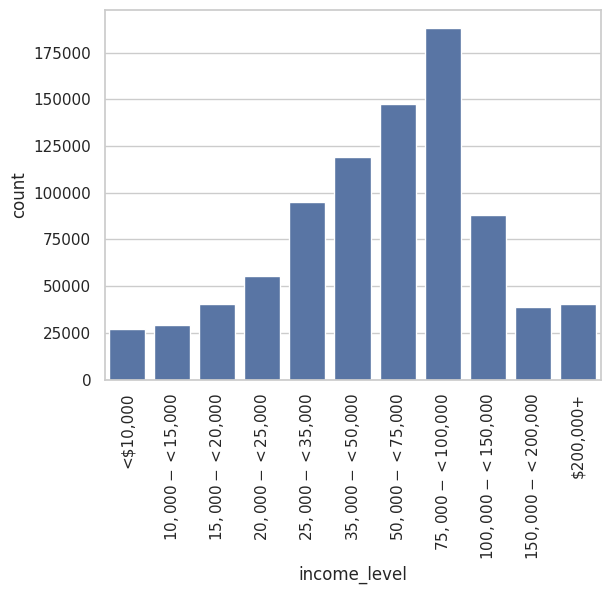

In [25]:
sns.countplot(data=df_1, x='income_level')
plt.xticks(rotation=90);

<Axes: xlabel='general_health', ylabel='count'>

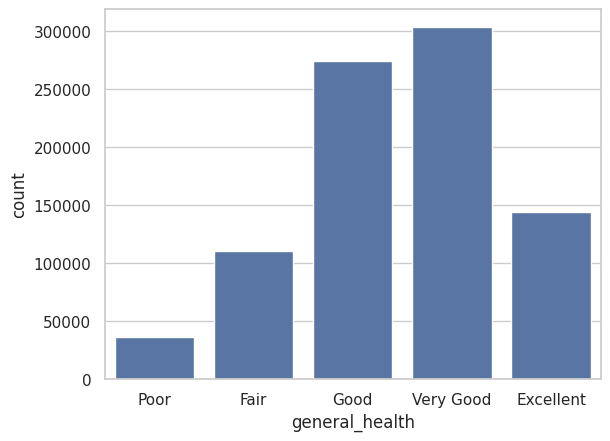

In [32]:
# fix general_health order
df_1.general_health.unique()
health_order = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']

health_cat_type = CategoricalDtype(categories=health_order, ordered=True)
df_1['general_health'] = df_1['general_health'].astype(health_cat_type)

sns.countplot(data=df_1, x='general_health')

In [26]:
df_1.last_checkup.unique()

<ArrowStringArray>
[     'Within the past year (< 12 months ago)',
                         '5 or more years ago',
 'Within the past 2 years (1 to <2 years ago)',
 'Within the past 5 years (2 to <5 years ago)',
                                       'Never']
Length: 5, dtype: str

In [33]:
rename_checkup = {
    "Never": "Never",
    "5 or more years ago": ">5 years",
    "Within the past 5 years (2 to <5 years ago)": "2 - <5 years",
    "Within the past 2 years (1 to <2 years ago)": "1 - <2 years",
    "Within the past year (< 12 months ago)": "<1 year",
}
df_1['last_checkup'] = df_1['last_checkup'].replace(rename_checkup)
df_1.last_checkup.unique()

order_checkup = ['Never', '>5 years', '2 - <5 years', '1 - <2 years', '<1 year']
checkup_cat_type = CategoricalDtype(categories=order_checkup, ordered=True)
df_1['last_checkup'] = df_1['last_checkup'].astype(checkup_cat_type)

In [58]:
df.diabetes.value_counts()

diabetes
Non-diabetic    734009
Diabetic        115697
Pre-diabetic     19613
Name: count, dtype: int64

In [ ]:
# fix diabetes order
order_diabetes = ['Non-diabetic', 'Pre-diabetic', 'Diabetic']
diabetes_cat_type = CategoricalDtype(categories=order_diabetes, ordered=True)
df_1['diabetes'] = df_1['diabetes'].astype(diabetes_cat_type)

<Axes: xlabel='diabetes', ylabel='count'>

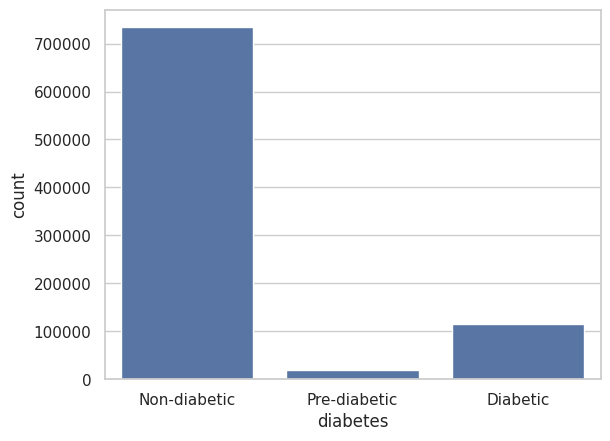

In [66]:
sns.countplot(data=df_1, x='diabetes')

In [60]:
df_1.info()

<class 'pandas.DataFrame'>
Index: 869319 entries, 0 to 1285656
Data columns (total 30 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   year                        869319 non-null  int64   
 1   age_group                   869319 non-null  category
 2   age                         869319 non-null  float64 
 3   sex                         869319 non-null  str     
 4   race                        869319 non-null  str     
 5   weight                      869319 non-null  float64 
 6   height                      869319 non-null  float64 
 7   bmi                         869319 non-null  float64 
 8   marital_status              869319 non-null  str     
 9   education_level             869319 non-null  category
 10  education                   869319 non-null  float64 
 11  employment_status           869319 non-null  str     
 12  income_level                869319 non-null  category
 13  income        

In [61]:
df_1.to_csv('../datasets/cleaned_data.csv', index=False)

In [2]:
# function to preserve order of categories when saving to csv and loading back
def load_with_category_order(filename):
    df = pd.read_csv(filename)


    # fix age_group order
    rename_age_groups = {
        '18 to 24': '18 - 24',
        '25 to 29': '25 - 29',
        '30 to 34': '30 - 34',
        '35 to 39': '35 - 39',
        '40 to 44': '40 - 44',
        '45 to 49': '45 - 49',
        '50 to 54': '50 - 54',
        '55 to 59': '55 - 59',
        '60 to 64': '60 - 64',
        '65 to 69': '65 - 69',
        '70 to 74': '70 - 74',
        '75 to 79': '75 - 79',
        '80 or older': '80+'
    }

    df['age_group'] = df['age_group'].replace(rename_age_groups)
    age_categories = ['18 - 24', '25 - 29', '30 - 34', '35 - 39', '40 - 44', '45 - 49', '50 - 54', '55 - 59', '60 - 64',
                    '65 - 69', '70 - 74', '75 - 79', '80+']
    age_cat_type = CategoricalDtype(categories=age_categories, ordered=True)
    # Apply to a column
    df['age_group'] = df['age_group'].astype(age_cat_type)
    
    
    # fix education_level order
    rename_education = {
        "Never attended school or only kindergarten" : "None or KG",
        "Grades 1 - 8 (Elementary)": "Elementary (1-8)",
        "Grades 9 - 11 (Some high school)": "Some high school (9-11)",
        "Grade 12 or GED (High school graduate)": "High school graduate (12 or GED)",
        "College 1 year to 3 years (Some college or technical school)": "Some college (1-3 years) or Technical school",
        "College 4 years or more (College graduate)": "College graduate (4+ years)"
    }

    df['education_level'] = df['education_level'].replace(rename_education)


    education_categories = ['None or KG', 'Elementary (1-8)', 'Some high school (9-11)', 'High school graduate (12 or GED)',
                            'Some college (1-3 years) or Technical school', 'College graduate (4+ years)']
    education_cat_type = CategoricalDtype(categories=education_categories, ordered=True)
    # Apply to a column
    df['education_level'] = df['education_level'].astype(education_cat_type)


    # fix income_level order
    rename_income = {
        'Less than $10,000': '<$10,000',
        '$10,000 to less than $15,000': '$10,000 - <$15,000',
        '$15,000 to less than $20,000': '$15,000 - <$20,000',
        '$20,000 to less than $25,000': '$20,000 - <$25,000',
        '$25,000 to less than $35,000': '$25,000 - <$35,000',
        '$35,000 to less than $50,000': '$35,000 - <$50,000',
        '$50,000 to less than $75,000': '$50,000 - <$75,000',
        '$75,000 or more': '$75,000 - <$100,000',
        '$75,000 to less than $100,000': '$75,000 - <$100,000',
        '$100,000 to less than $150,000': '$100,000 - <$150,000',
        '$150,000 to less than $200,000': '$150,000 - <$200,000',
        '$200,000 or more': '$200,000+'
    }

    df['income_level'] = df["income_level"].replace(rename_income)


    income_categories = ['<$10,000', '$10,000 - <$15,000', '$15,000 - <$20,000', '$20,000 - <$25,000', '$25,000 - <$35,000',
                        '$35,000 - <$50,000', '$50,000 - <$75,000', '$75,000 - <$100,000', '$100,000 - <$150,000',
                        '$150,000 - <$200,000', '$200,000+']
    income_cat_type = CategoricalDtype(categories=income_categories, ordered=True)
    # Apply to a column
    df['income_level'] = df['income_level'].astype(income_cat_type)


    # fix general_health order
    df.general_health.unique()
    health_order = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']

    health_cat_type = CategoricalDtype(categories=health_order, ordered=True)
    df['general_health'] = df['general_health'].astype(health_cat_type)

    sns.countplot(data=df, x='general_health')

    # fix last_checkup order
    rename_checkup = {
        "Never": "Never",
        "5 or more years ago": ">5 years",
        "Within the past 5 years (2 to <5 years ago)": "2 - <5 years",
        "Within the past 2 years (1 to <2 years ago)": "1 - <2 years",
        "Within the past year (< 12 months ago)": "<1 year",
    }
    df['last_checkup'] = df['last_checkup'].replace(rename_checkup)
    df.last_checkup.unique()

    order_checkup = ['Never', '>5 years', '2 - <5 years', '1 - <2 years', '<1 year']
    checkup_cat_type = CategoricalDtype(categories=order_checkup, ordered=True)
    df['last_checkup'] = df['last_checkup'].astype(checkup_cat_type)


    # fix diabetes order
    order_diabetes = ['Non-diabetic', 'Pre-diabetic', 'Diabetic']
    diabetes_cat_type = CategoricalDtype(categories=order_diabetes, ordered=True)
    df['diabetes'] = df['diabetes'].astype(diabetes_cat_type)

    return df


<class 'pandas.DataFrame'>
RangeIndex: 869319 entries, 0 to 869318
Data columns (total 30 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   year                        869319 non-null  int64   
 1   age_group                   869319 non-null  category
 2   age                         869319 non-null  float64 
 3   sex                         869319 non-null  str     
 4   race                        869319 non-null  str     
 5   weight                      869319 non-null  float64 
 6   height                      869319 non-null  float64 
 7   bmi                         869319 non-null  float64 
 8   marital_status              869319 non-null  str     
 9   education_level             869319 non-null  category
 10  education                   869319 non-null  float64 
 11  employment_status           869319 non-null  str     
 12  income_level                869319 non-null  category
 13  income    

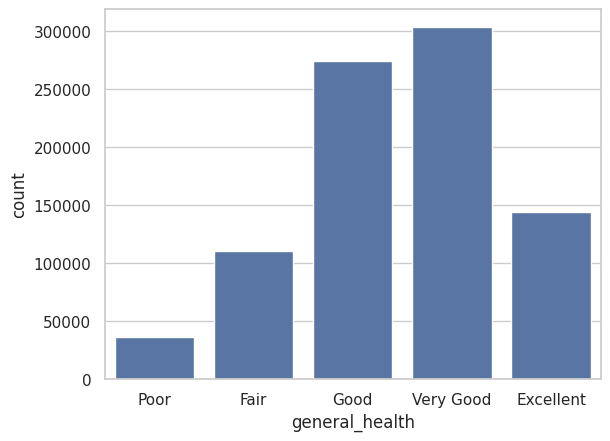

In [3]:
df = load_with_category_order("../datasets/cleaned_data.csv")
df.info()

# EDA Proper

In [5]:
df.head()

,year,age_group,age,sex,race,weight,height,bmi,marital_status,education_level,education,employment_status,income_level,income,general_health,gen_health,physical_health_days,mental_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,last_checkup,l_checkup,has_personal_doctor,diabetes
0,2019,40 to 44,5.0,Female,White,220.0,66.0,35.51,Never married,Some college (1-3 years) or Technical school,5.0,A homemaker,"<$10,000",1.0,Very Good,2.0,0.0,30.0,False,True,False,Yes,False,False,False,False,<1 year,1.0,"Yes, only one",Non-diabetic
1,2019,60 to 64,9.0,Male,White,150.0,66.0,24.21,Divorced,Some college (1-3 years) or Technical school,5.0,Unable to work,"<$10,000",1.0,Fair,4.0,3.0,12.0,True,True,False,Yes,False,False,False,False,<1 year,1.0,No,Non-diabetic
2,2019,45 to 49,6.0,Female,White,148.0,61.0,27.96,Divorced,High school graduate (12 or GED),4.0,Employed for wages,"<$10,000",1.0,Good,3.0,0.0,10.0,True,True,True,Yes,False,False,False,False,<1 year,1.0,"Yes, only one",Diabetic
3,2019,45 to 49,6.0,Male,White,220.0,71.0,30.68,Married,High school graduate (12 or GED),4.0,Employed for wages,"$75,000 - <$100,000",8.0,Very Good,2.0,0.0,0.0,True,True,False,No,False,False,False,False,<1 year,1.0,No,Non-diabetic
4,2019,65 to 69,10.0,Male,Black,283.0,73.0,37.33,Widowed,High school graduate (12 or GED),4.0,Retired,"$15,000 - <$20,000",3.0,Fair,4.0,30.0,0.0,False,True,False,Yes,True,False,False,False,<1 year,1.0,"Yes, only one",Diabetic


## Univariate Analysis
### Year

In [5]:
df.year.value_counts()

year
2023    292024
2021    289550
2019    287745
Name: count, dtype: int64

<Axes: xlabel='year', ylabel='count'>

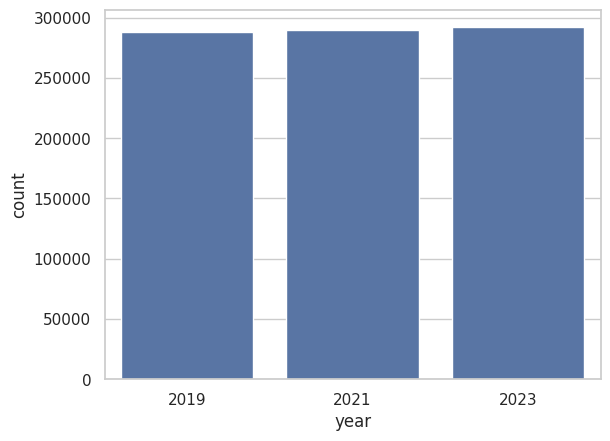

In [4]:
sns.countplot(data=df, x='year')

Year distribution is balanced.

### Age

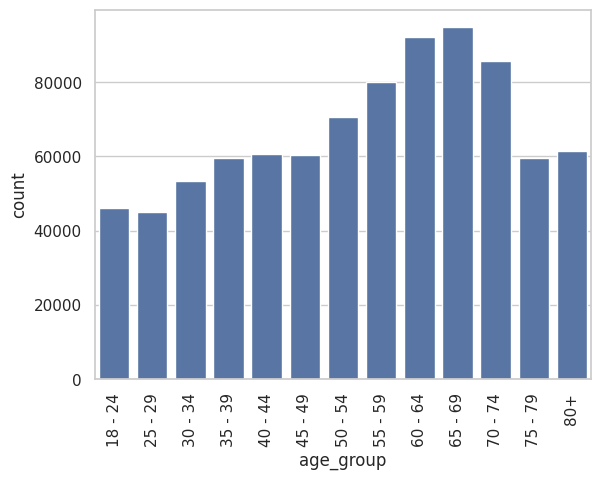

In [78]:
sns.countplot(data=df, x='age_group')
plt.xticks(rotation=90);

gradual increase in representation of age groups with increasing age.. Non 75 or older in the data.

### Sex and Race

<Axes: xlabel='sex', ylabel='count'>

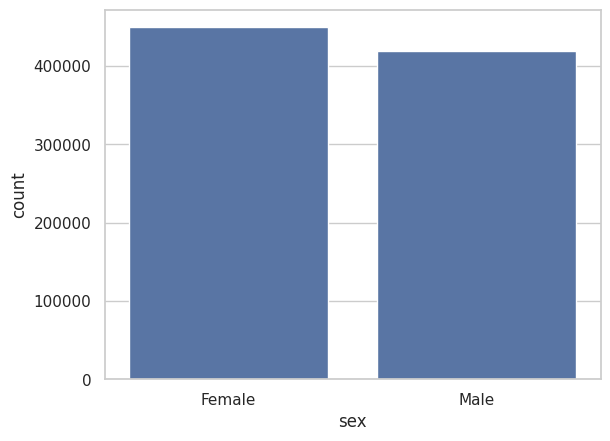

In [11]:
sns.countplot(data=df, x='sex')

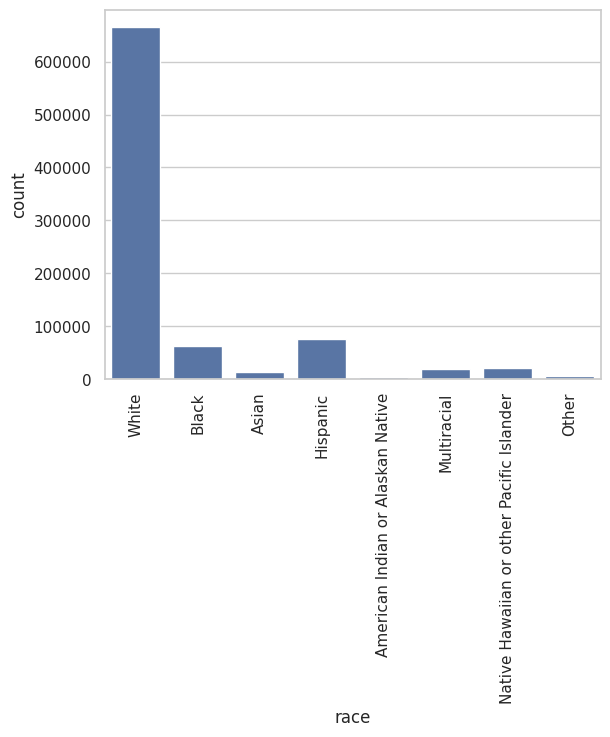

In [13]:
sns.countplot(data=df, x='race')
plt.xticks(rotation=90);

More females than males.
White predominance.

(50.0, 400.0)

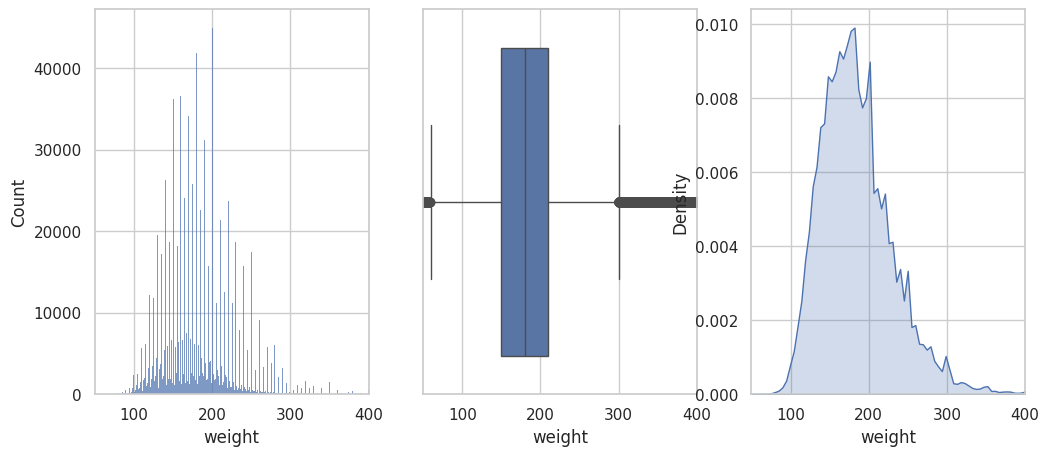

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

ax1 = sns.histplot(data=df, x='weight', ax=axes[0])
ax1.set_xlim(50, 400)

ax2 = sns.boxplot(data=df, x='weight', ax=axes[1], orientation='vertical')
ax2.set_xlim(50, 400)

ax3 = sns.kdeplot(data=df, x='weight', ax=axes[2], fill=True)
ax3.set_xlim(50, 400)

(50.0, 80.0)

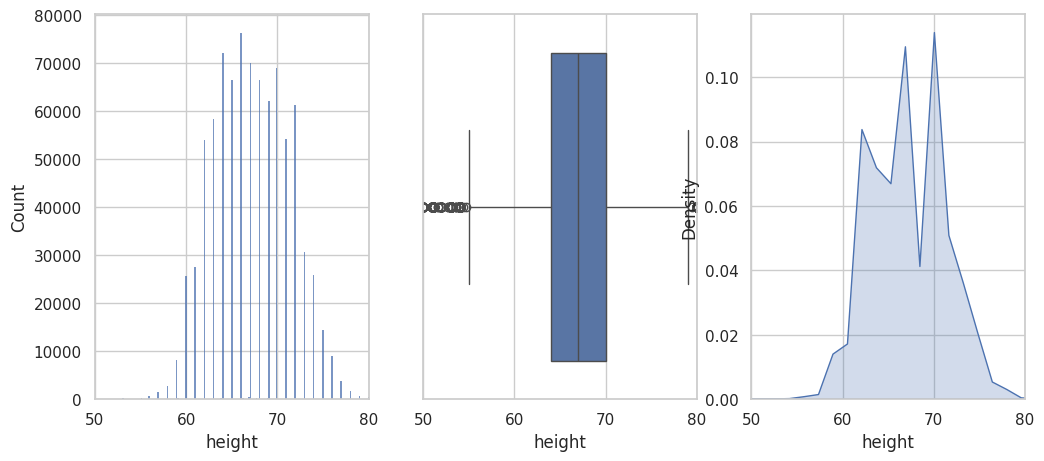

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

ax1 = sns.histplot(data=df, x='bmi', ax=axes[0])
ax1.set_xlim(50, 80)

ax2 = sns.boxplot(data=df, x='bmi', ax=axes[1], orientation='vertical')
ax2.set_xlim(50, 80)

ax3 = sns.kdeplot(data=df, x='bmi', ax=axes[2], fill=True)
ax3.set_xlim(50, 80)

(0.0, 70.0)

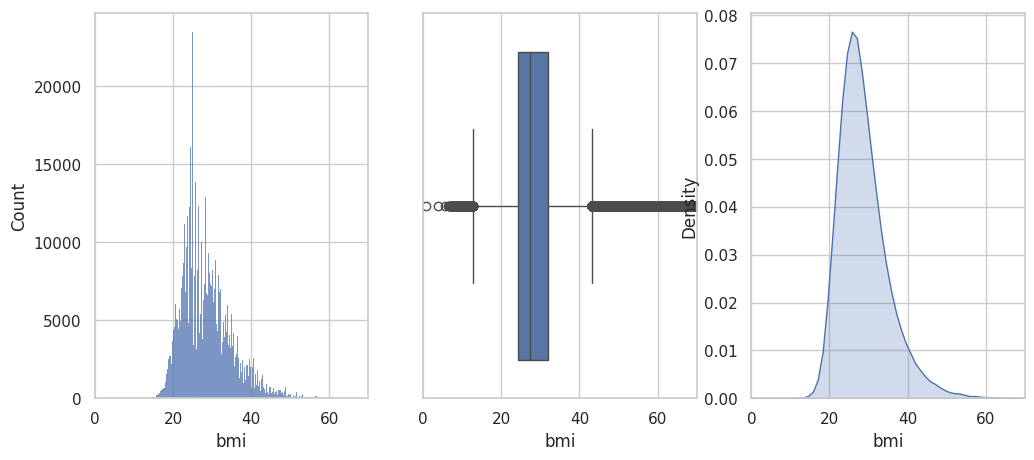

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

ax1 = sns.histplot(data=df, x='bmi', ax=axes[0])
ax1.set_xlim(0, 70)

ax2 = sns.boxplot(data=df, x='bmi', ax=axes[1], orientation='vertical')
ax2.set_xlim(0, 70)

ax3 = sns.kdeplot(data=df, x='bmi', ax=axes[2], fill=True)
ax3.set_xlim(0, 70)

In [31]:
df.describe()

,year,age,weight,height,bmi,education,income,gen_health,physical_health_days,mental_health_days,l_checkup
count,869319.000000,869319.000000,869319.000000,869319.000000,869319.000000,869319.000000,869319.000000,869319.000000,869319.000000,869319.000000,869319.000000
mean,2021.009844,7.555367,184.378634,67.173150,28.642386,5.078265,6.655114,2.529493,4.113399,4.133051,1.356910
std,1.633279,3.488967,46.903543,4.199285,6.559001,0.973716,2.344857,1.041449,8.519620,8.097524,0.808164
min,2019.000000,1.000000,50.000000,24.800000,0.770000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
25%,2019.000000,5.000000,150.000000,64.000000,24.270000,4.000000,5.000000,2.000000,0.000000,0.000000,1.000000
50%,2021.000000,8.000000,180.000000,67.000000,27.450000,5.000000,7.000000,2.000000,0.000000,0.000000,1.000000
75%,2023.000000,10.000000,210.000000,70.000000,31.870000,6.000000,8.000000,3.000000,3.000000,4.000000,1.000000
max,2023.000000,13.000000,999.000000,339.370000,246.960000,6.000000,11.000000,5.000000,30.000000,30.000000,5.000000


#### Marital Status

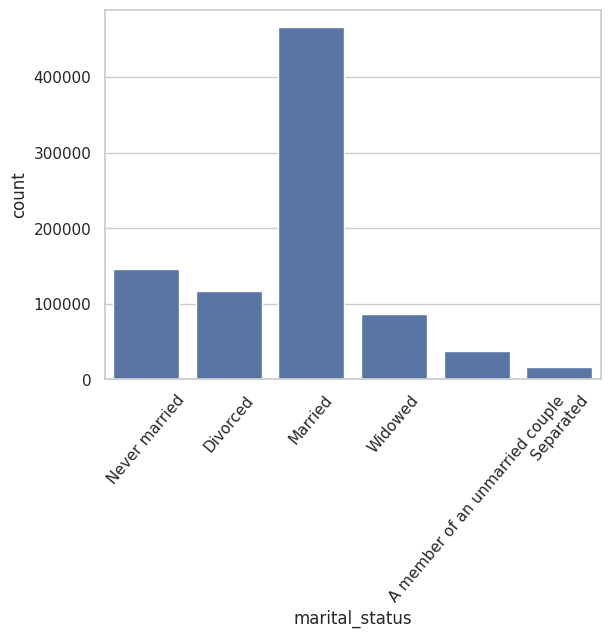

In [34]:
sns.countplot(data=df, x='marital_status')
plt.xticks(rotation=50);

#### Level of Education

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'None or KG'),
  Text(1, 0, 'Elementary (1-8)'),
  Text(2, 0, 'Some high school (9-11)'),
  Text(3, 0, 'High school graduate (12 or GED)'),
  Text(4, 0, 'Some college (1-3 years) or Technical school'),
  Text(5, 0, 'College graduate (4+ years)')])

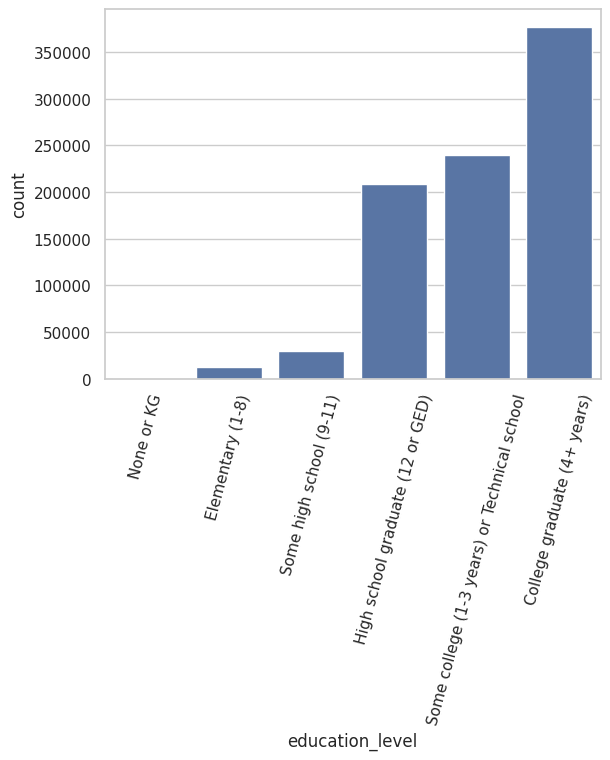

In [37]:
sns.countplot(data=df, x='education_level')
plt.xticks(rotation=75)

In [38]:
df.education_level.value_counts()

education_level
College graduate (4+ years)                     377139
Some college (1-3 years) or Technical school    240180
High school graduate (12 or GED)                208809
Some high school (9-11)                          29919
Elementary (1-8)                                 12633
None or KG                                         639
Name: count, dtype: int64

In [39]:
df.columns

Index(['year', 'age_group', 'age', 'sex', 'race', 'weight', 'height', 'bmi',
       'marital_status', 'education_level', 'education', 'employment_status',
       'income_level', 'income', 'general_health', 'gen_health',
       'physical_health_days', 'mental_health_days', 'exercise',
       'smoked_100_cigarettes', 'drinks_alcohol', 'high_bp', 'had_stroke',
       'had_heart_attack', 'had_coronary_heart_disease', 'cost_barrier',
       'last_checkup', 'l_checkup', 'has_personal_doctor', 'diabetes'],
      dtype='str')

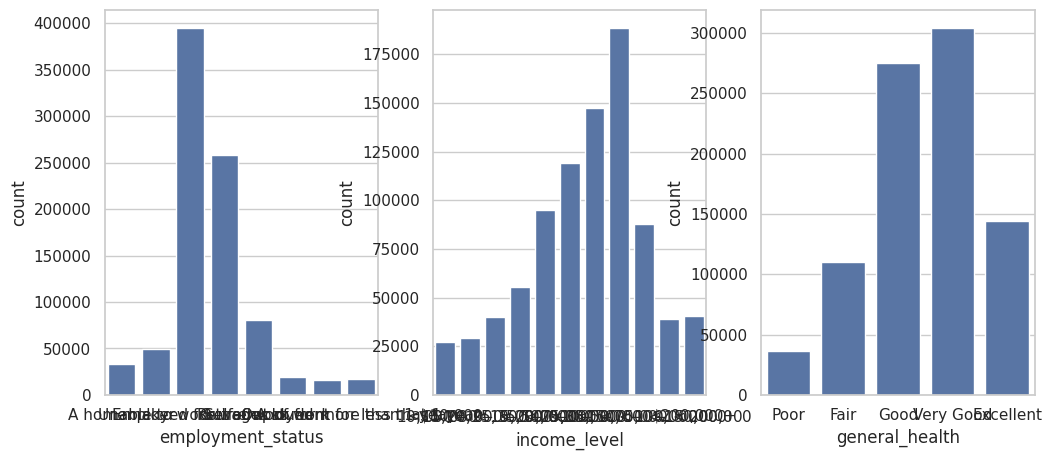

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
ax1 = sns.countplot(data=df, x='employment_status', ax=axes[0])
ax2 = sns.countplot(data=df, x='income_level', ax=axes[1])
ax3 = sns.countplot(data=df, x='general_health', ax=axes[2])

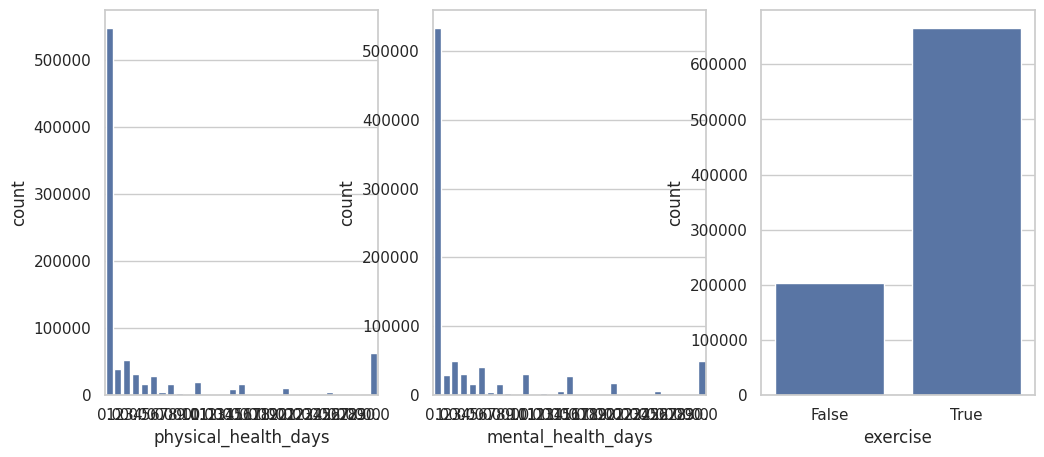

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
ax1 = sns.countplot(data=df, x='physical_health_days', ax=axes[0])
ax2 = sns.countplot(data=df, x='mental_health_days', ax=axes[1])
ax3 = sns.countplot(data=df, x='exercise', ax=axes[2])

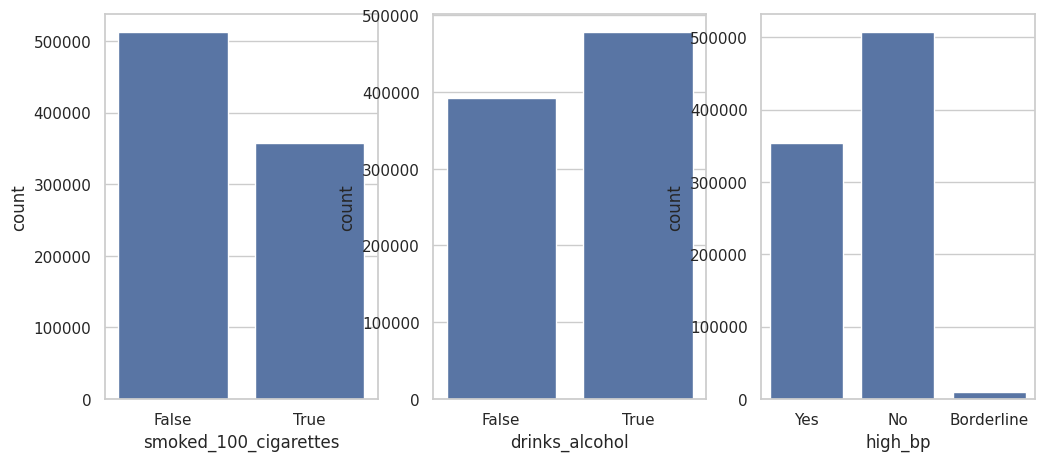

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
ax1 = sns.countplot(data=df, x='smoked_100_cigarettes', ax=axes[0])
ax2 = sns.countplot(data=df, x='drinks_alcohol', ax=axes[1])
ax3 = sns.countplot(data=df, x='high_bp', ax=axes[2])

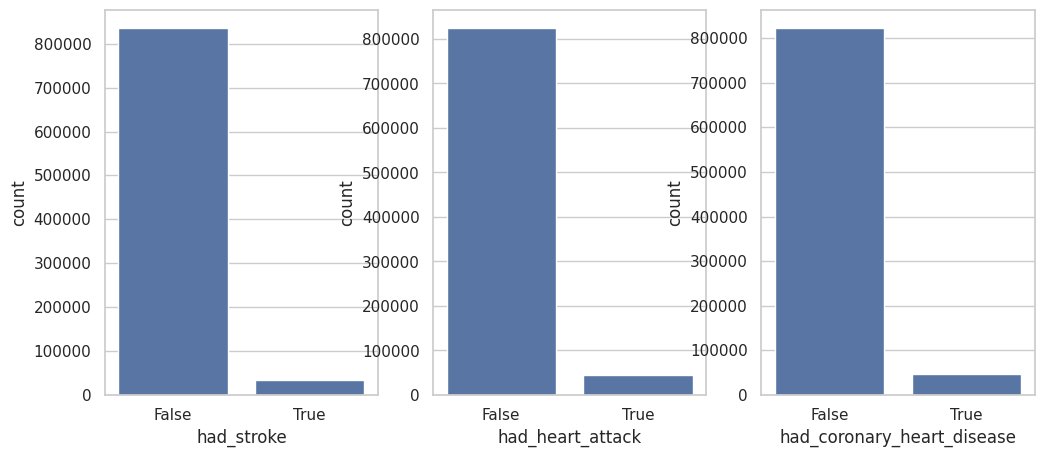

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
ax1 = sns.countplot(data=df, x='had_stroke', ax=axes[0])
ax2 = sns.countplot(data=df, x='had_heart_attack', ax=axes[1])
ax3 = sns.countplot(data=df, x='had_coronary_heart_disease', ax=axes[2])

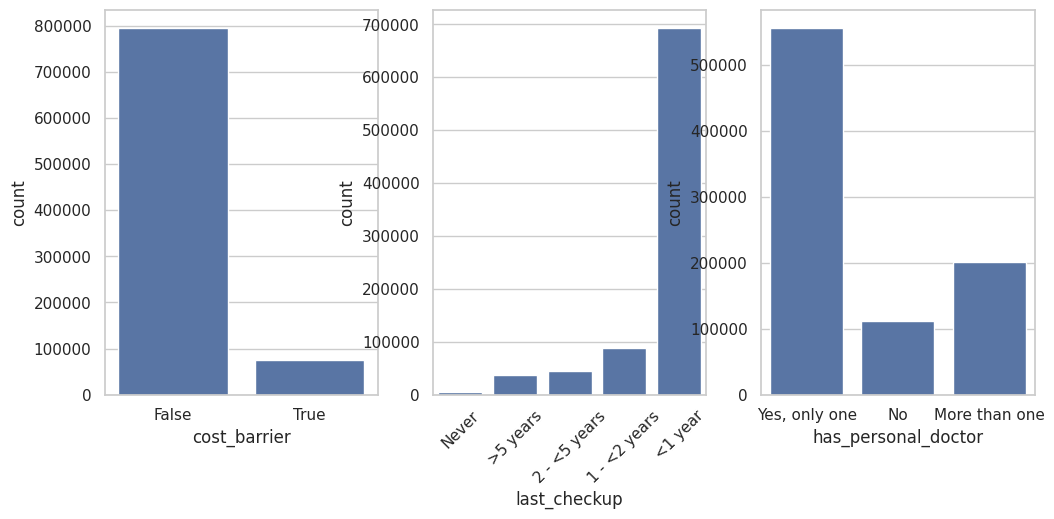

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
ax1 = sns.countplot(data=df, x='cost_barrier', ax=axes[0])
ax2 = sns.countplot(data=df, x='last_checkup', ax=axes[1])
ax2.tick_params(axis='x', labelrotation=45)
ax3 = sns.countplot(data=df, x='has_personal_doctor', ax=axes[2])

<Axes: xlabel='diabetes', ylabel='count'>

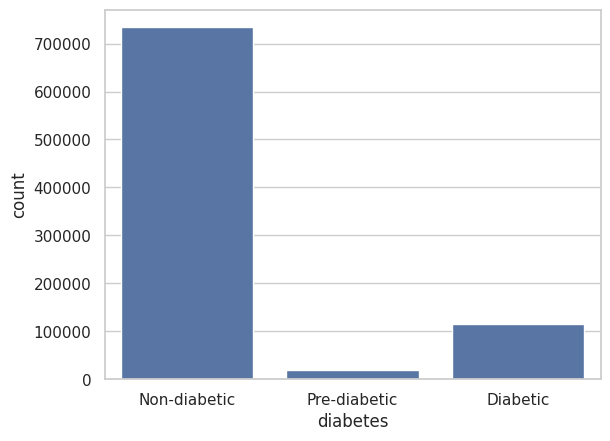

In [71]:
sns.countplot(data=df, x='diabetes')

In [57]:
df.diabetes.value_counts()

diabetes
Non-diabetic    734009
Diabetic        115697
Pre-diabetic     19613
Name: count, dtype: int64

### Bivariate Analysis

In [72]:
df.head()

,year,age_group,age,sex,race,weight,height,bmi,marital_status,education_level,education,employment_status,income_level,income,general_health,gen_health,physical_health_days,mental_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,last_checkup,l_checkup,has_personal_doctor,diabetes
0,2019,40 - 44,5.0,Female,White,220.0,66.0,35.51,Never married,Some college (1-3 years) or Technical school,5.0,A homemaker,"<$10,000",1.0,Very Good,2.0,0.0,30.0,False,True,False,Yes,False,False,False,False,<1 year,1.0,"Yes, only one",Non-diabetic
1,2019,60 - 64,9.0,Male,White,150.0,66.0,24.21,Divorced,Some college (1-3 years) or Technical school,5.0,Unable to work,"<$10,000",1.0,Fair,4.0,3.0,12.0,True,True,False,Yes,False,False,False,False,<1 year,1.0,No,Non-diabetic
2,2019,45 - 49,6.0,Female,White,148.0,61.0,27.96,Divorced,High school graduate (12 or GED),4.0,Employed for wages,"<$10,000",1.0,Good,3.0,0.0,10.0,True,True,True,Yes,False,False,False,False,<1 year,1.0,"Yes, only one",Diabetic
3,2019,45 - 49,6.0,Male,White,220.0,71.0,30.68,Married,High school graduate (12 or GED),4.0,Employed for wages,"$75,000 - <$100,000",8.0,Very Good,2.0,0.0,0.0,True,True,False,No,False,False,False,False,<1 year,1.0,No,Non-diabetic
4,2019,65 - 69,10.0,Male,Black,283.0,73.0,37.33,Widowed,High school graduate (12 or GED),4.0,Retired,"$15,000 - <$20,000",3.0,Fair,4.0,30.0,0.0,False,True,False,Yes,True,False,False,False,<1 year,1.0,"Yes, only one",Diabetic


In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 869319 entries, 0 to 869318
Data columns (total 30 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   year                        869319 non-null  int64   
 1   age_group                   869319 non-null  str     
 2   age                         869319 non-null  float64 
 3   sex                         869319 non-null  str     
 4   race                        869319 non-null  str     
 5   weight                      869319 non-null  float64 
 6   height                      869319 non-null  float64 
 7   bmi                         869319 non-null  float64 
 8   marital_status              869319 non-null  str     
 9   education_level             869319 non-null  category
 10  education                   869319 non-null  float64 
 11  employment_status           869319 non-null  str     
 12  income_level                869319 non-null  category
 13  income    

#### Diabetes vs Year

<Axes: xlabel='year', ylabel='count'>

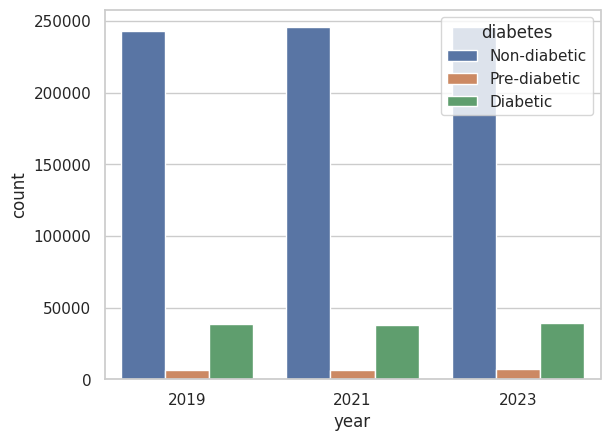

In [90]:
sns.countplot(data=df, x='year', hue='diabetes')

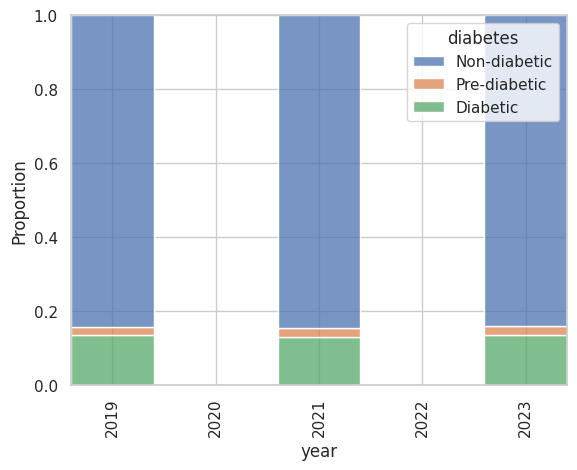

In [91]:
sns.histplot(
    data=df,
    x="year",
    hue="diabetes",
    multiple="fill",
    stat="proportion",
    discrete=True,
    shrink=0.8
)
plt.xticks(rotation=90);

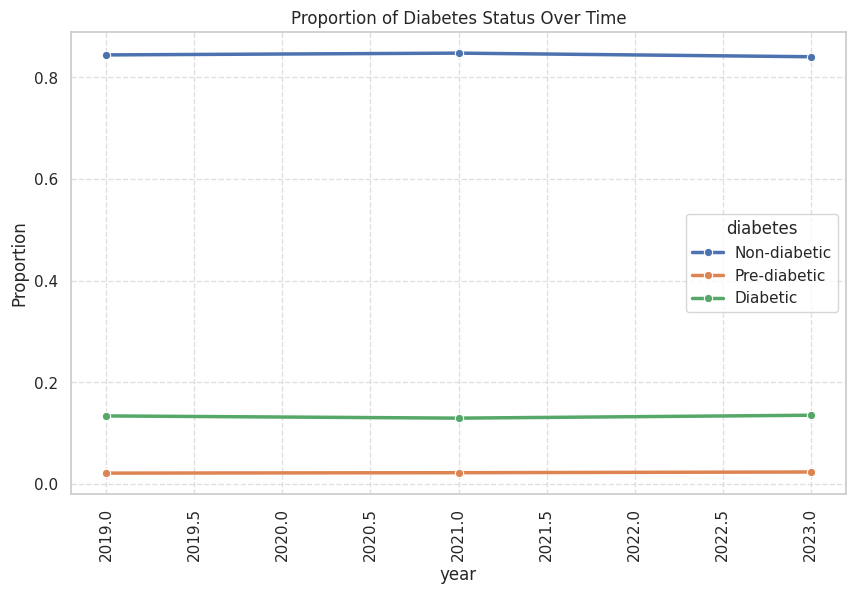

In [99]:
# 1. Calculate the proportions (normalized by row/index)
proportions = pd.crosstab(df['year'], df['diabetes'], normalize='index').reset_index()
# 2. Melt the data so it's back in a "long format" that Seaborn loves
df_melted = proportions.melt(id_vars='year', value_name='proportion')

# 3. Plot using sns.lineplot
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_melted, 
    x='year', 
    y='proportion', 
    hue='diabetes', 
    marker='o',     # Adds dots to each year point
    linewidth=2.5
)

plt.title("Proportion of Diabetes Status Over Time")
plt.ylabel("Proportion")
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.6) # Adds a clean grid for tracking trends
plt.show()

In [101]:
proportions

diabetes,year,Non-diabetic,Pre-diabetic,Diabetic
0,2019,0.844390,0.021533,0.134077
1,2021,0.847898,0.022380,0.129722
2,2023,0.840790,0.023755,0.135455


In [ ]:
sns.barplot(x='year', y='')

No notable change in diabetes incidence across the years

#### Diabetes vs age

This only mirrors the age distribution showing consistenly across all three diabetes status.

<Axes: xlabel='diabetes', ylabel='count'>

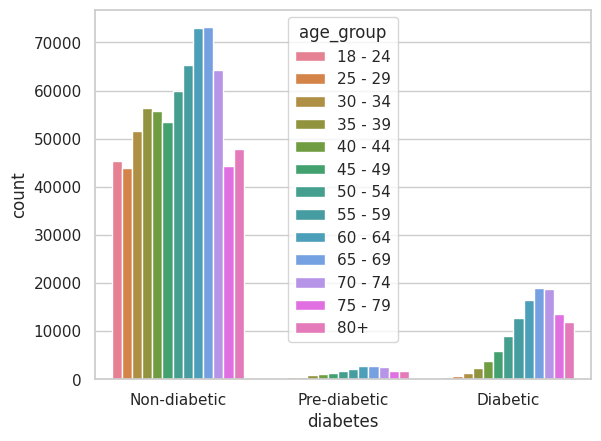

In [77]:
sns.countplot(data=df, x='diabetes', hue='age_group')

<Axes: xlabel='age_group', ylabel='count'>

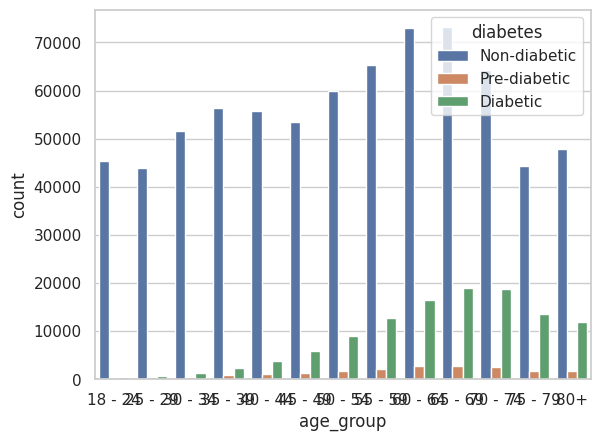

In [85]:
sns.countplot(data=df, x='age_group', hue='diabetes')

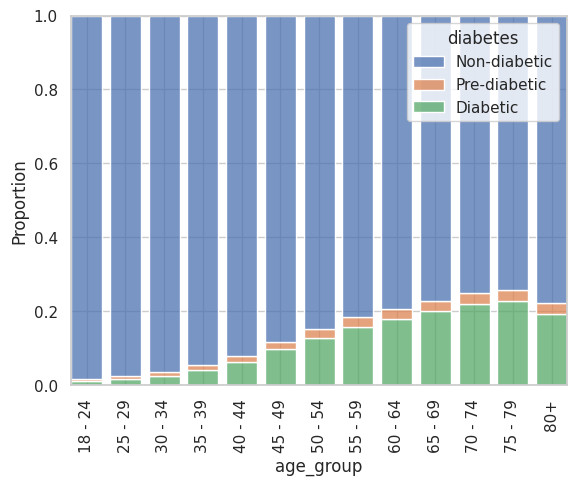

In [81]:
sns.histplot(
    data=df,
    x="age_group",
    hue="diabetes",
    multiple="fill",
    stat="proportion",
    discrete=True,
    shrink=0.8
)
plt.xticks(rotation=90);

Clear trend. The risk of diabetes increases with increasing age.

Same trend shown below with the barplot.

<Axes: xlabel='diabetes', ylabel='age'>

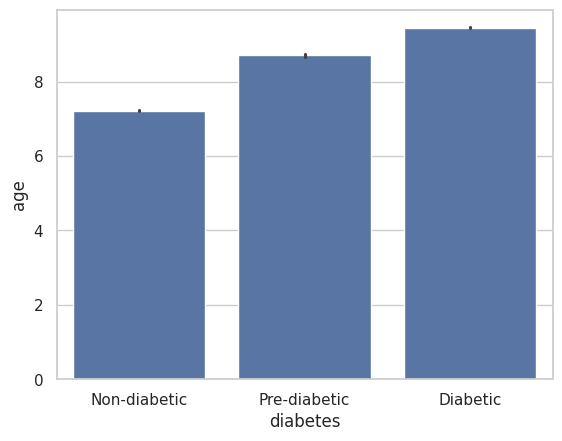

In [10]:
sns.barplot(data=df, x='diabetes', y='age')

#### Diabetes vs Sex

<Axes: xlabel='sex', ylabel='Proportion'>

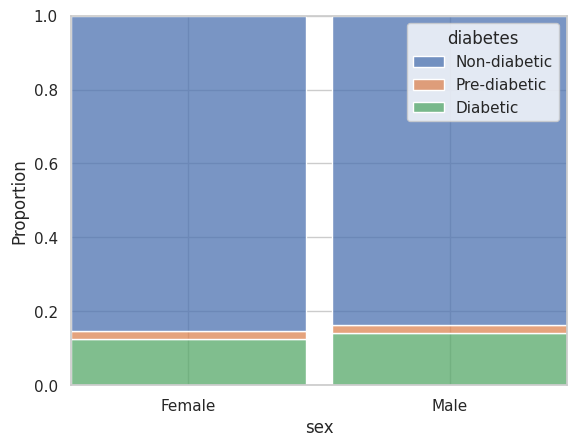

In [16]:
sns.histplot(data=df, x='sex', hue='diabetes', multiple='fill', stat='proportion', shrink=0.9)

Shows higher proportions of males are diabetic, and more females are non-diabetic.

#### Diabetes vs Race

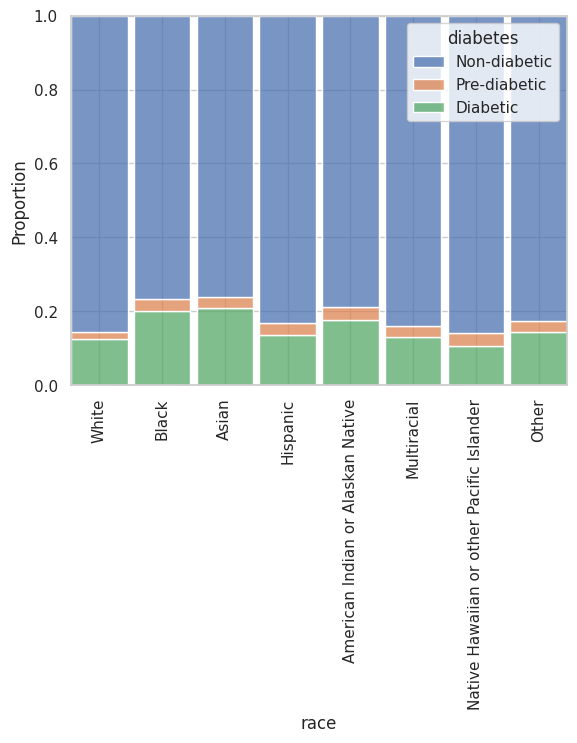

In [19]:
sns.histplot(data=df, x='race', hue='diabetes', multiple='fill', stat='proportion', shrink=0.9)
plt.xticks(rotation=90);

Higher incidence in Blacks, Asians, and Native Americans.

### Dibetes vs (Weight, Height, BMI)

<Axes: xlabel='diabetes', ylabel='weight'>

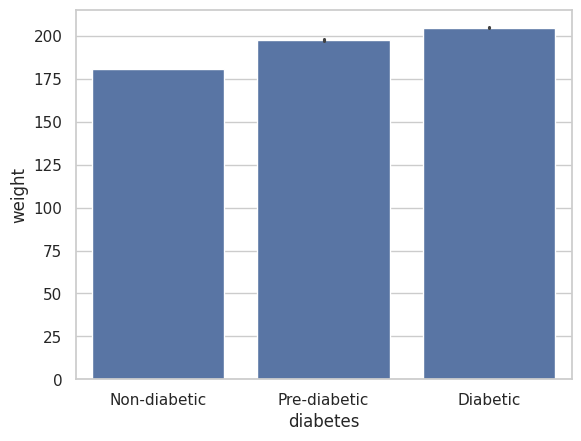

In [20]:
sns.barplot(data=df, x='diabetes', y='weight')

<Axes: xlabel='diabetes', ylabel='height'>

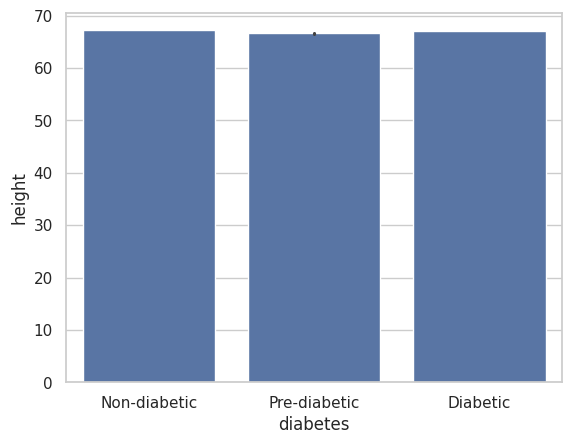

In [22]:
sns.barplot(data=df, x='diabetes', y='height')

<Axes: xlabel='diabetes', ylabel='bmi'>

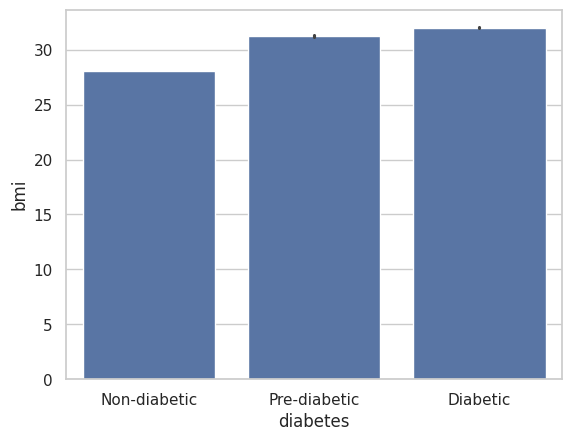

In [23]:
sns.barplot(data=df, x='diabetes', y='bmi')

Increasing trend with weght and bmi. No clear trend with height.

#### vs Marital Status

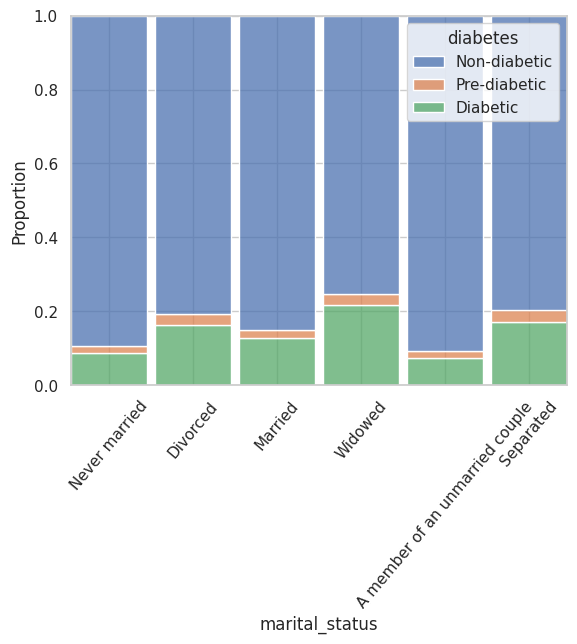

In [25]:
sns.histplot(data=df, x='marital_status', hue='diabetes', multiple='fill', stat='proportion', shrink=0.9)
plt.xticks(rotation=50);

In [26]:
df.columns

Index(['year', 'age_group', 'age', 'sex', 'race', 'weight', 'height', 'bmi',
       'marital_status', 'education_level', 'education', 'employment_status',
       'income_level', 'income', 'general_health', 'gen_health',
       'physical_health_days', 'mental_health_days', 'exercise',
       'smoked_100_cigarettes', 'drinks_alcohol', 'high_bp', 'had_stroke',
       'had_heart_attack', 'had_coronary_heart_disease', 'cost_barrier',
       'last_checkup', 'l_checkup', 'has_personal_doctor', 'diabetes'],
      dtype='str')

#### vs Level of Education

<Axes: xlabel='diabetes', ylabel='education'>

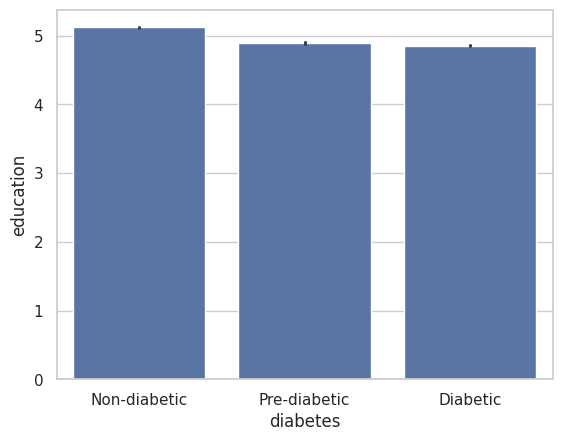

In [27]:
sns.barplot(data=df, x='diabetes', y='education')

Higher levels of education, lower chance of being diabetic.

#### vs Income

<Axes: xlabel='diabetes', ylabel='income'>

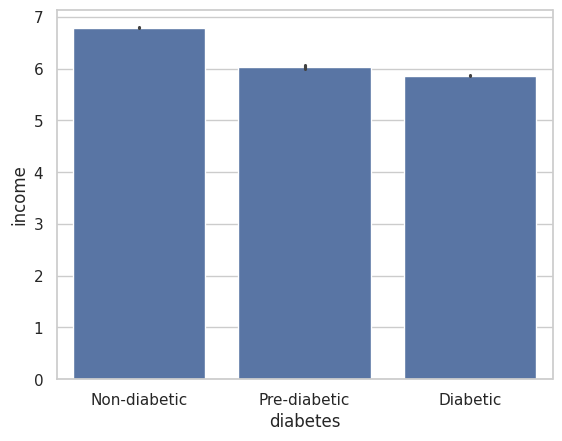

In [28]:
sns.barplot(data=df, x='diabetes', y='income')

Similar trend as education. Higher income relates with a lower risk of diabetes, and vice versa.

#### vs Employment Status

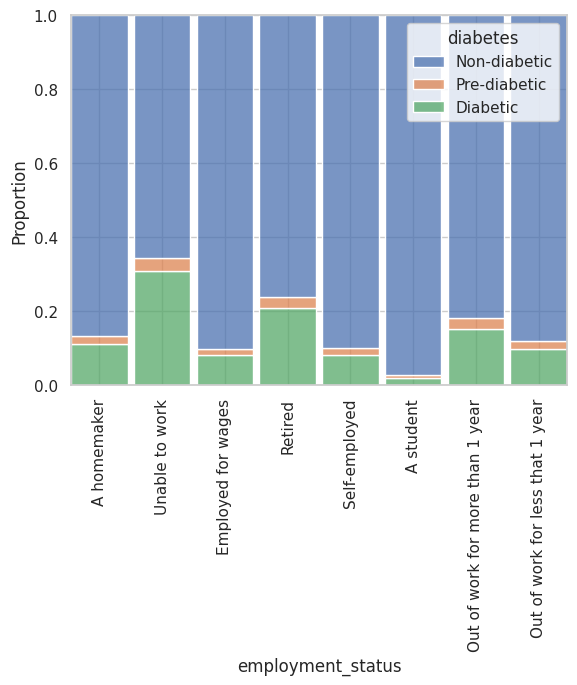

In [31]:
sns.histplot(data=df, x='employment_status', hue='diabetes', multiple='fill', stat='proportion', shrink=0.9)
plt.xticks(rotation=90);

Unable to work, retired, out of work for more than a year, all have higher incidence of diabetes compared to the other groups.

Unable to work might point to comorbidities.

Lowest incidence among students.

#### vs General Health

<Axes: xlabel='diabetes', ylabel='gen_health'>

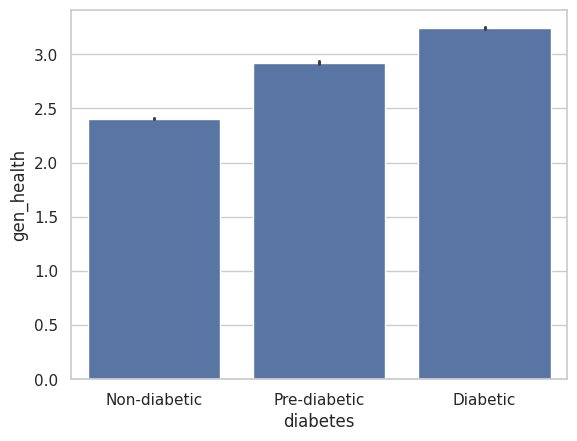

In [35]:
sns.barplot(data=df, x='diabetes', y='gen_health')

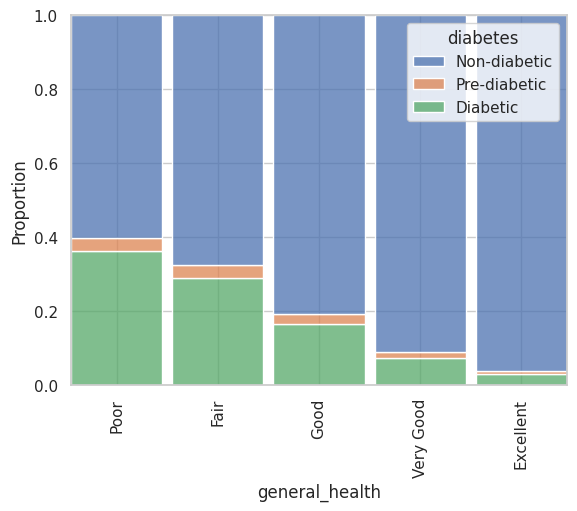

In [37]:
sns.histplot(data=df, x='general_health', hue='diabetes', multiple='fill', stat='proportion', shrink=0.9)
plt.xticks(rotation=90);

Better self-rated health among non-diabetics compared to diabetics. 

_N.B: Data is coded such that 1=Excellent and 5=Poor_

The stacked bar plot shows the consistent trend of reducing incidence of diabetes as health rating increases.

#### vs (Physical Health Days, Mental Health Days)

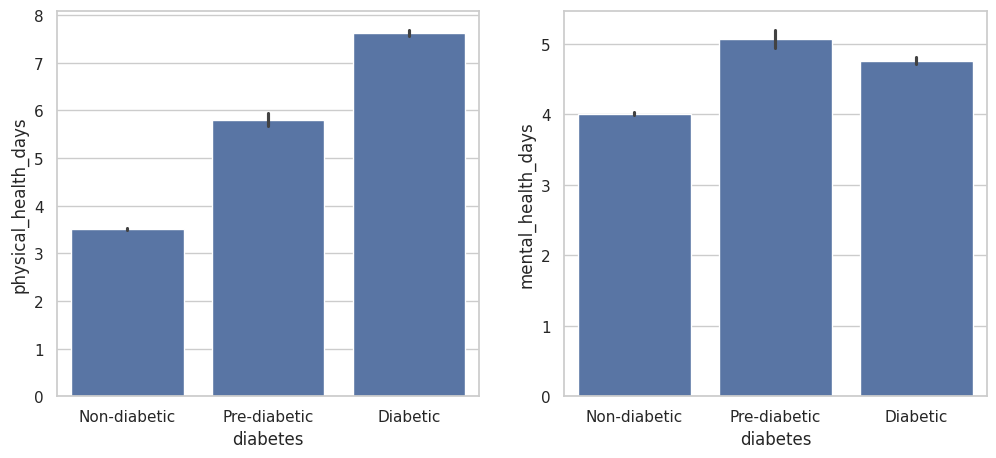

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = sns.barplot(data=df, y='physical_health_days', x='diabetes', fill=True, ax=axes[0])
ax2 = sns.barplot(data=df, y='mental_health_days', x='diabetes', fill=True, ax=axes[1])


Non-diabetic people report lower days of poor physical and mental health in a month. Diabetics report higher.

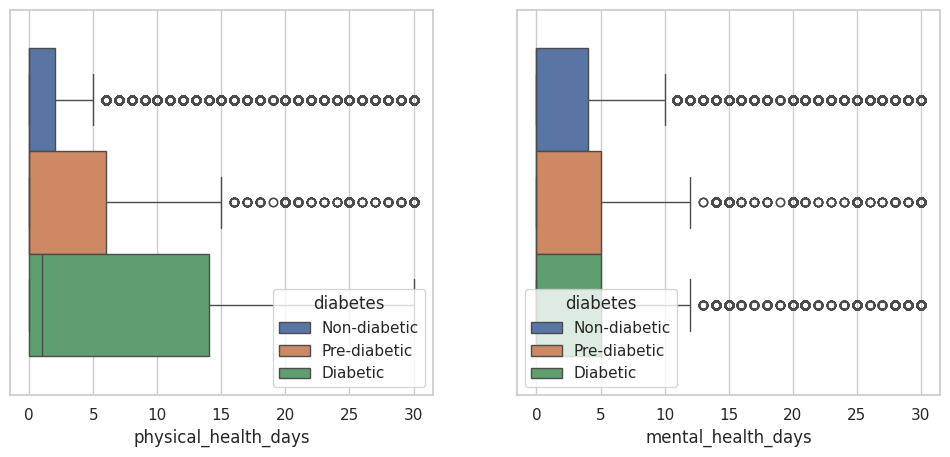

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax1 = sns.boxplot(data=df, x='physical_health_days', hue='diabetes', fill=True, ax=axes[0])
ax2 = sns.boxplot(data=df, x='mental_health_days', hue='diabetes', fill=True, ax=axes[1])


In [49]:
df.columns

Index(['year', 'age_group', 'age', 'sex', 'race', 'weight', 'height', 'bmi',
       'marital_status', 'education_level', 'education', 'employment_status',
       'income_level', 'income', 'general_health', 'gen_health',
       'physical_health_days', 'mental_health_days', 'exercise',
       'smoked_100_cigarettes', 'drinks_alcohol', 'high_bp', 'had_stroke',
       'had_heart_attack', 'had_coronary_heart_disease', 'cost_barrier',
       'last_checkup', 'l_checkup', 'has_personal_doctor', 'diabetes'],
      dtype='str')

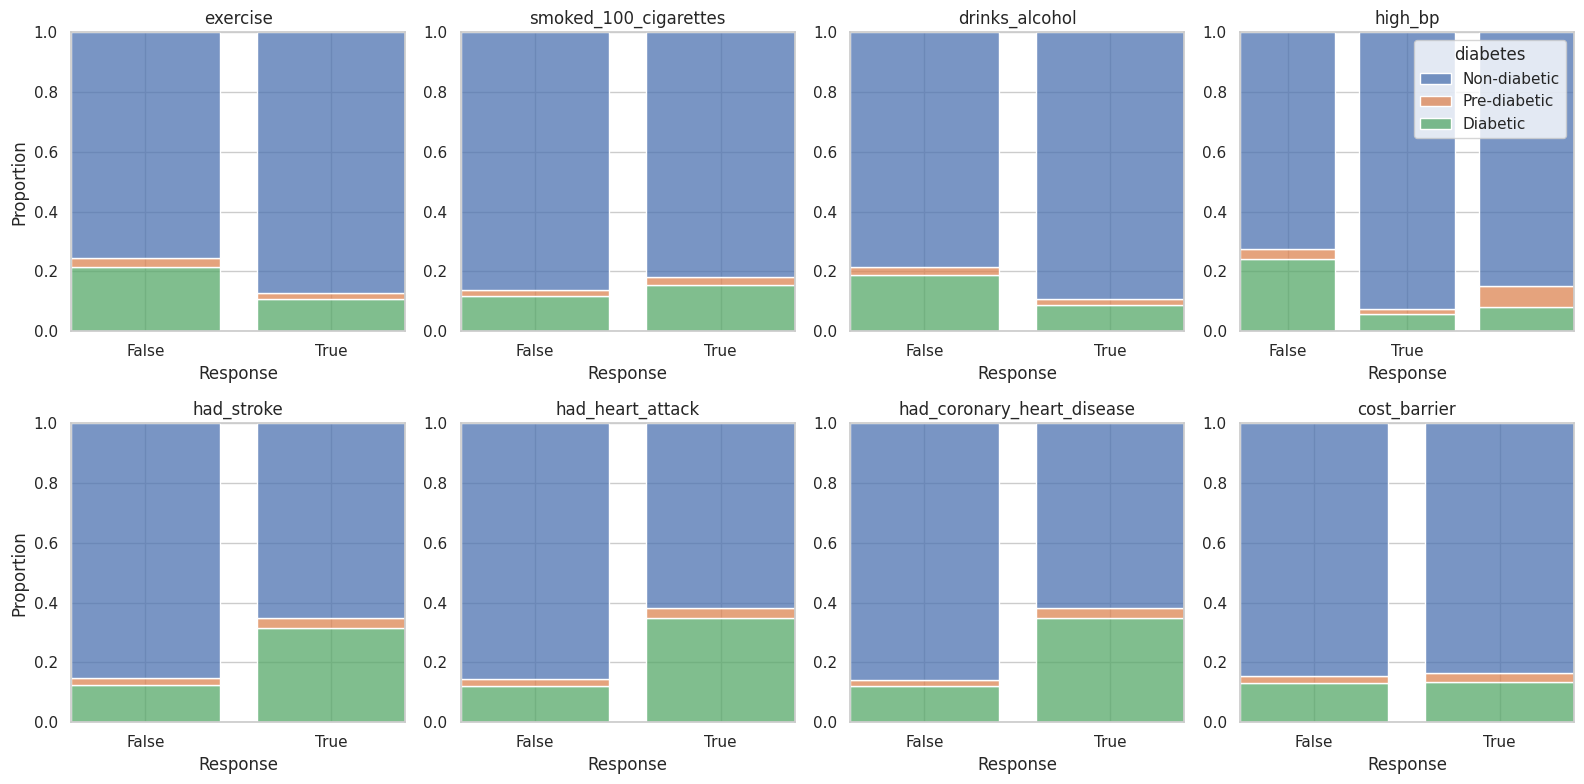

In [51]:
risk_factors = [
    'exercise', 'smoked_100_cigarettes', 'drinks_alcohol', 'high_bp', 
    'had_stroke', 'had_heart_attack', 'had_coronary_heart_disease', 'cost_barrier'
]

# Set up the overall figure size
plt.figure(figsize=(16, 8))

# Loop through the columns directly using 1-based indexing for subplot
for i, column in enumerate(risk_factors, 1):
    plt.subplot(2, 4, i)  # Creates a 2x4 grid and activates the i-th plot
    
    sns.histplot(
        data=df,
        x=column,
        hue="diabetes",
        multiple="fill",
        stat="proportion",
        discrete=True,
        shrink=0.8,
        legend=(i == 4)  # Drops repetitive legends; only draws it on the 4th plot
    )
    plt.title(column)
    plt.xlabel("Response")
    plt.ylabel("Proportion" if i in [1, 5] else "") # Only label y-axis on the left edge
    plt.xticks(ticks=[0, 1], labels=['False', 'True'])
    
plt.tight_layout()
plt.show()

<Axes: xlabel='diabetes', ylabel='l_checkup'>

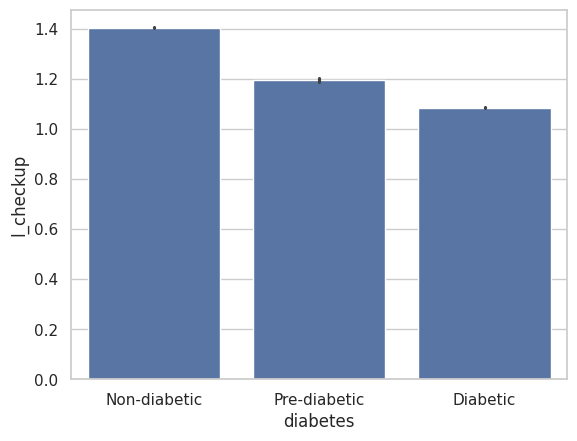

In [52]:
sns.barplot(data=df, x='diabetes', y='l_checkup')

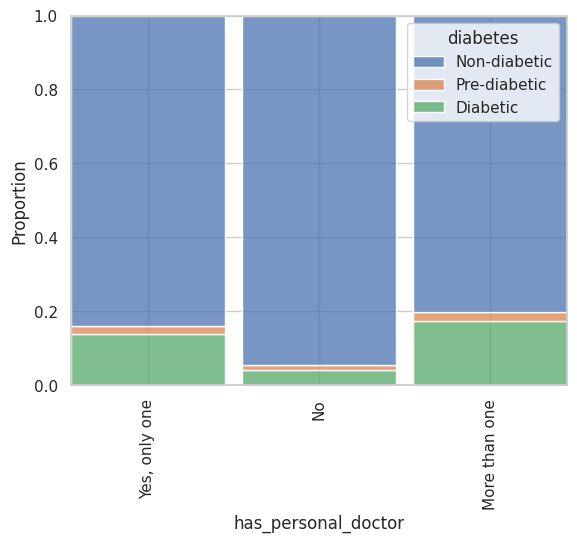

In [53]:
sns.histplot(data=df, x='has_personal_doctor', hue='diabetes', multiple='fill', stat='proportion', shrink=0.9)
plt.xticks(rotation=90);